## Import External Packages

In [1]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

## Import Tender Analysis Packages

In [2]:
from src import (
    SifFile,
    find_sif_files,
    compute_background,
    extract_signal,
    CurvatureCorrection,
    OnePot,
    OnePotRIXS
)

## Set Data Directory

In [28]:
# Na2SO4 example data set
#DATA = '/sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/Na2SO4/*.sif'
DATA = './data/Na2SO4/*.sif'

files = find_sif_files(DATA)

print(f'{len(files)} *.sif files found in {DATA[:-5]}:\n {files[0]}, {files[1]}... \n ... {files[-1]}')

84 *.sif files found in ./data/Na2SO4/:
 ./data/Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_2465.00.sif, ./data/Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_2467.00.sif... 
 ... ./data/Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_dark.sif


## 1. Reading a SIF file

`SifFile` wraps `sif_parser` for the image data and parses the acquisition
comment for additional parameters (e.g. `I0` / `I1` / `mono`).

In [9]:
sif = SifFile(files[30])

### A. Metadata
Various metadata is available from the file comment including:
- X-ray parameters: `I0`, `I1`, `mono`,
- CCD parameters: `exptime`, `numkins`
- Motor positions: `vert`,`Sx`, `Sy`

In [10]:
sif_dict = {
 "I0" : sif.I0,
 "I1" : sif.I1,
 "exposure time" : sif.exposure_time,
 "mono" : sif.mono,
 "num_frames" : sif.num_frames,
 "shape" : sif.shape,
 "metadata" : sif.metadata,
 "info" : sif.info
 }
sif_dict

{'I0': 8972.0,
 'I1': 57.0,
 'exposure time': 1.0,
 'mono': 2482.8,
 'num_frames': 1,
 'shape': (512, 2048),
 'metadata': {'mono': 2482.8,
  'I0': 8972.0,
  'I1': 57.0,
  'exptime': 1.0,
  'numkins': nan,
  'vert': 42.6981},
 'info': OrderedDict([('SifVersion', 65567),
              ('ExperimentTime', 1252658467),
              ('DetectorTemperature', -52.0),
              ('ExposureTime', 1.0),
              ('CycleTime', 2.577),
              ('AccumulatedCycleTime', 2.577),
              ('AccumulatedCycles', 1),
              ('StackCycleTime', 2.577),
              ('PixelReadoutTime', 1e-06),
              ('GainDAC', 0.0),
              ('GateWidth', 0.0),
              ('GratingBlaze', 1.6e-05),
              ('DetectorType', 'DV436'),
              ('DetectorDimensions', (2048, 2048)),
              ('OriginalFilename', b'Acquisition'),
              ('ShutterTime', (0.01, 0.0)),
              ('spectrograph', '999'),
              ('GateGain', 0.0),
              ('GateDelay'

### B. Raw Image and Spectrum
Frames can be accessed via indices using the `frame` method.   

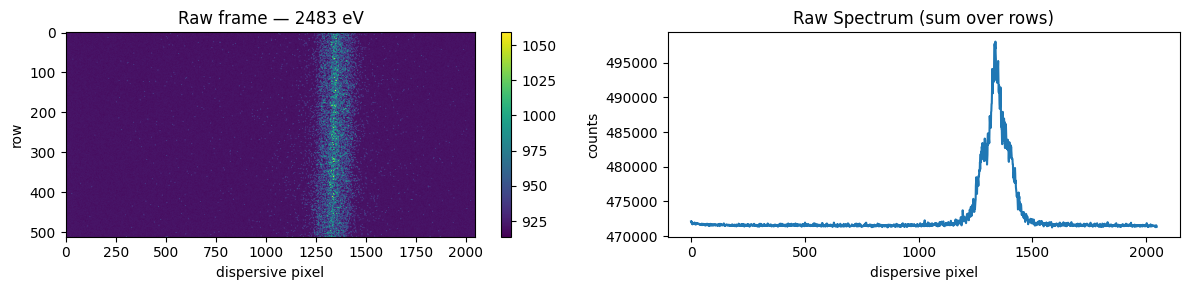

In [11]:
frame = sif.frame(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
im = ax[0].imshow(frame, aspect='auto', vmin=np.percentile(frame, 1), vmax=np.percentile(frame, 99.5))
ax[0].set(title=f'Raw frame — {sif.mono:.0f} eV', xlabel='dispersive pixel', ylabel='row')
fig.colorbar(im, ax=ax[0])
ax[1].plot(frame.sum(axis=0))
ax[1].set(title='Raw Spectrum (sum over rows)', xlabel='dispersive pixel', ylabel='counts')
plt.tight_layout()

## 2. `OnePot` - XES Pipeline

`OnePot` ties the analysis stages together:   
Resolve files → background → extract → curvature-correct.   
**Note:** `bcg=None` computes the background from the data.

In this example we will analyze Mo VtC on the \[CpMo(CO)<sub>3</sub>\]<sub>2</sub> dimer complex.

### A. Loading .sif files

In [3]:
# Dimolybdenum sample example data set rXES at 2524.20 eV
DATA2 = './data/CPMoITriCO3Dimer/*MoL3val_2523.00eV_0*.sif'

files2 = find_sif_files(DATA2)

print(f'{len(files2)} *.sif files found in {DATA2[:-5]}:')
files2

18 *.sif files found in ./data/CPMoITriCO3Dimer/*MoL3val_2523.00eV_0:


['./data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_01.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_01_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_02.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_02_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_03.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_03_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_04.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_04_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_05.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_05_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_06.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dim

In [4]:
Mosif = SifFile(files2[0])
print('Data shape (num_frames, y-pixel, x-pixel):', Mosif.data.shape)
print('Number of frames:', Mosif.num_frames)

Data shape (num_frames, y-pixel, x-pixel): (80, 512, 2048)
Number of frames: 80


### B. `OnePot` Analysis

Analysis with parameters:
- `bcg = none` -> Compute background from the data.
- `histograms = True` -> Calculate the histogram for determining ADU filter thresholds.
- `thresholds = ...` -> Thresholds used for noise discrimination.
- `file_nbrs = [0]` -> Select which files to analyze (0-based indices; `[0]` = first file).

In [5]:
op = OnePot(files2, bcg=None, histograms=True, threshold=[100, 170, 350], file_nbrs=[0])
xes = op.run()
spec = xes.spectrum()

Text(0, 0.5, 'Counts')

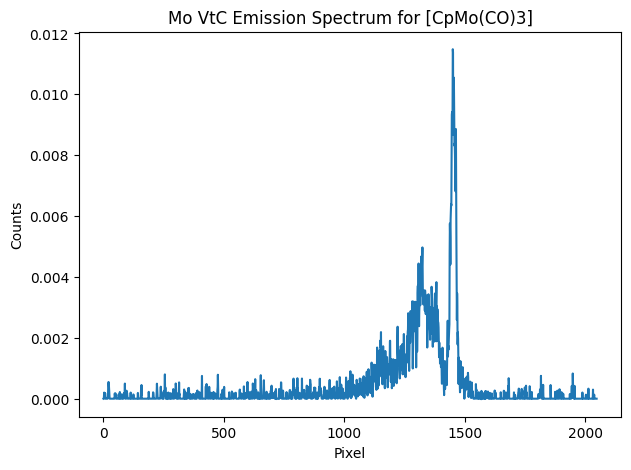

In [6]:
plt.figure(figsize=(7,5))

plt.plot(spec / np.trapezoid(spec))
plt.title("Mo VtC Emission Spectrum for [CpMo(CO)3]")
plt.xlabel("Pixel")
plt.ylabel("Counts")

Analysis with same parameters as above, selecting/slicing the first 20 frames.
- `scan_nbrs = range(20)` -> Select only frames 0-19 (0-based) for analysis from each file.

In [7]:
op2 = OnePot(files2, bcg=None, histograms=True, threshold=[100, 170, 350], file_nbrs=[0], scan_nbrs=range(20))
xes2 = op2.run()
spec2 = xes2.spectrum()

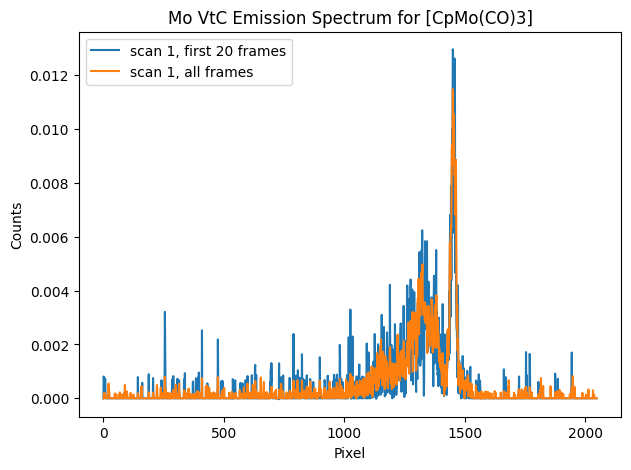

In [8]:
plt.figure(figsize=(7,5))

plt.plot(spec2 / np.trapezoid(spec2), label = 'scan 1, first 20 frames')
plt.plot(spec / np.trapezoid(spec), label = 'scan 1, all frames')
plt.title("Mo VtC Emission Spectrum for [CpMo(CO)3]")
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.legend()

### C. Diagnostic histograms - Determining ADU thresholds

The `threshold` argument controls the single-photon event extraction — separating real X-ray events from readout noise and cosmic rays, in detector ADU (counts). Internally it is always the canonical **four** values `[bcg_cutoff, low, xray, hi]` (the `Thresholds` dataclass), each with a distinct job:

| Value        | Role | Acts on |
|--------------|------|---------|
| `bcg_cutoff` | Loose cutoff used only by the `evolution=True` curvature pre-pass; unused in the normal single-pass path. | — |
| `low`        | 3×3 neighbourhood gate — is there a photon event at this pixel? | `3×3 binned` (per-pixel) |
| `xray`       | Minimum per-event (connected-component) intensity to keep the event. | grain intensities (per-event) |
| `hi`         | Upper ceiling — pixels above this are rejected as cosmics / high-energy hits. | `raw − background` (per-pixel) |

**Supplying fewer values.** You can pass 1–4 values and the rest are filled in (mirroring the MATLAB `onepot.m` defaulting). Given input `v`:

| Input             | Expands to `[bcg_cutoff, low, xray, hi]` |
|-------------------|-------------------------------------------|
| `None` (default)  | `[60, 100, 170, 2000]` |
| `[x]` (scalar)    | `[0.8·x, x, 1.1·x, 65536]` |
| `[a, b]`          | `[0.8·b, b, 1.1·b, b]` |
| `[a, b, c]`       | `[a, b, 1.1·b, c]` — i.e. `bcg_cutoff, low, hi`; `xray` is derived |
| `[a, b, c, d]`    | `[a, b, c, d]` (used as-is) |

The common three-element form (e.g. `threshold=[100, 170, 350]`) means `bcg_cutoff=100`, `low=170`, `hi=350`, with `xray` auto-filled to `187`. Note that in the 1-, 2-, and 3-element forms `xray` is always tied to `1.1·low` — **to set `low`, `xray`, and `hi` independently, supply the full 4-element array** (e.g. `[100, 170, 210, 350]`).

> **Two different 3-element groupings (easy to trip on):** what you *supply* is `[bcg_cutoff, low, hi]`, but what the extractor actually consumes is `[low, xray, hi]` (the `bcg_cutoff` only feeds the evolution pre-pass). Text exports always record the full four-element array in their header for provenance.

**Choosing thresholds.** Run with `histograms=True` and inspect the ADU histograms below. Distributions are grouped by shared ADU scale/quantity into three panels, with each threshold line **colour-matched to the trace it filters**:

- **Left — raw & background** (per-pixel, detector pedestal ~925 ADU): shown for context; no threshold acts here in the normal path.
- **Middle — the two background-subtracted per-pixel frames** (both start near 0, so they share an axis): `low` (blue) gates the `3×3 binned` trace — set it just above the noise floor; `hi` (red) is the cosmic cut on `raw − background` — set it below the cosmic tail.
- **Right — per-event grain intensities**: `xray` (green) is the minimum grain intensity kept — set it above the noise bump so only real events survive.

The right panel is a *per-event* quantity (a grain sums several pixels), which is why it can't share an axis with the per-pixel panels.

In [9]:
H = xes.histograms
th = op.thresholds

print('Thresholds [bcg_cutoff, low, xray, hi] =', th.as_array())

Thresholds [bcg_cutoff, low, xray, hi] = [100. 170. 187. 350.]


In [ ]:
adu = np.arange(H['raw'].size)

# Group distributions that share an ADU scale/quantity into one box, so the
# four histograms collapse to three panels. The threshold line is colour-matched
# to the trace it filters.
def xhi(*keys, pad=1.15, floor=0):
    """Upper x-limit covering ~99.9% of the summed histogram(s)."""
    h = sum(H[k] for k in keys)
    q = int(np.searchsorted(np.cumsum(h), 0.999 * h.sum()))
    return max(q * pad, floor)

def xlo(*keys, pad=20):
    nz = np.flatnonzero(sum(H[k] for k in keys))
    return max(0, nz.min() - pad) if nz.size else 0

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# [0] raw & background — per-pixel on the detector-pedestal scale (~925 ADU).
# No threshold acts here in the normal path (only the evolution-only bcg_cutoff).
ax[0].semilogy(adu, H['raw'], color='0.4', lw=1, label='raw data')
ax[0].semilogy(adu, H['background'], color='C1', lw=1, label='background')
ax[0].set(title='Raw & background\n(detector pedestal — no threshold)',
          xlabel='per-pixel counts [ADU]', ylabel='frequency',
          xlim=(xlo('raw', 'background'), xhi('raw', 'background')))
ax[0].legend(fontsize=8)

# [1] both per-pixel background-subtracted frames (share scale, start near 0):
# low (blue) gates the 3x3 binned frame; hi (red) is the cosmic cut on raw-bcg.
ax[1].semilogy(adu, H['bkg_free'], color='C3', lw=1, label='raw − background')
ax[1].semilogy(adu, H['binned'], color='C0', lw=1, label='3×3 binned')
ax[1].axvline(th.low, color='C0', ls='--', lw=1.5, label=f'low = {th.low:.0f}')
ax[1].axvline(th.hi, color='C3', ls='--', lw=1.5, label=f'hi = {th.hi:.0f}')
ax[1].set(title='Per-pixel gates\nlow → 3×3 binned · hi → raw−bcg (cosmics)',
          xlabel='per-pixel counts [ADU]', ylabel='frequency',
          xlim=(0, xhi('bkg_free', 'binned', floor=1.2 * th.hi)))
ax[1].legend(fontsize=8)

# [2] per-event grain intensities (a grain sums several pixels — its own scale):
# xray (green) is the minimum grain intensity kept.
ax[2].semilogy(adu, H['xray'], color='C2', lw=1, label='extracted grains')
ax[2].axvline(th.xray, color='C2', ls='--', lw=1.5, label=f'xray = {th.xray:.0f}')
ax[2].set(title='Per-event grains\nxray = min grain intensity kept',
          xlabel='per-event counts [ADU]', ylabel='frequency',
          xlim=(0, xhi('xray', floor=1.3 * th.xray)))
ax[2].legend(fontsize=8)

plt.tight_layout()

print('X-ray event peak at ADU =', int(np.argmax(H['xray'])))

### D. Curvature correction

The emission line is not perfectly straight across the dispersive axis: its
position along the 512 spatial rows drifts as a smooth (roughly quadratic)
function of dispersive pixel — the detector "banana." `CurvatureCorrection`
fits that drift by cross-correlation and shifts each dispersive column back into
vertical alignment.

**Note:** the correction shifts pixels *vertically* (along the rows that are
summed to make a spectrum). The row-summed 1-D emission spectrum
`signal.sum(axis=0)` is therefore almost unchanged by construction — summing a
column is invariant to shifting values within it. The effect shows up in the
**2-D image** and in any narrow emission-band cut (e.g. the RIXS/HERFD band),
*not* in the row-summed spectrum. Below we show the 2-D signal before/after and
the emission-line spatial profile (sum over the dispersive axis), which sharpens
as the banana is straightened.

fitted curvature coefficients t = [-1.07654913e-06  3.85417587e-03 -2.57097537e+00]
row-summed spectrum max relative change: 2.37%


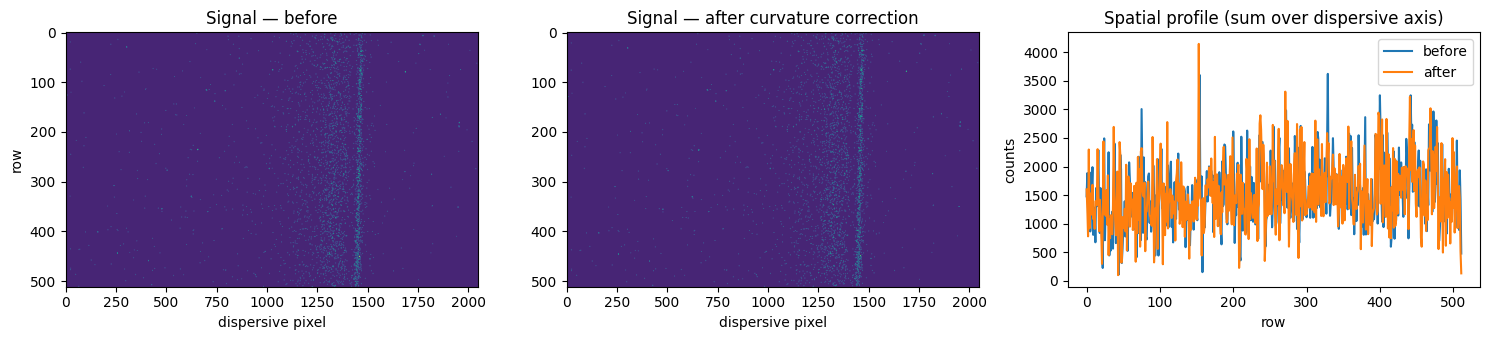

In [20]:
# Fit and apply the curvature correction to the extracted signal.
cc = CurvatureCorrection()
signal = xes.signal
corrected, _ = cc.fit_apply(signal)
print('fitted curvature coefficients t =', cc.t)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))

vmax = np.percentile(signal, 99.8)
ax[0].imshow(signal, aspect='auto', vmax=vmax)
ax[0].set(title='Signal — before', xlabel='dispersive pixel', ylabel='row')
ax[1].imshow(corrected, aspect='auto', vmax=vmax)
ax[1].set(title='Signal — after curvature correction', xlabel='dispersive pixel')

# emission-line spatial profile (sum over dispersive axis) — sharpens after
ax[2].plot(signal.sum(axis=1), label='before')
ax[2].plot(corrected.sum(axis=1), label='after')
ax[2].set(title='Spatial profile (sum over dispersive axis)',
          xlabel='row', ylabel='counts')
ax[2].legend()
plt.tight_layout()

# The row-summed spectrum barely changes — quantify it:
sb, sa = signal.sum(axis=0), corrected.sum(axis=0)
print(f'row-summed spectrum max relative change: '
      f'{np.abs(sa - sb).max() / np.abs(sb).max():.2%}')

## 3. `OnePotRIXS` - RIXS + HERFD/XAS

The `OnePotRIXS` pipeline analyzes a complete set of emission spectra at fixed incident x-ray energies, assembling the emission pixel vs incident energy RIXS map. 

Use the `OnePotRIXS.herfd` method to select a RIXS cut at specified emission pixel (energy) and width.
Default is `central_pix = None`, where the central emission pixel is determined by gaussian fit to the summed emission spectrum. 

In this example, we will process the RIXS data for solid Na<sub>2</sub>SO<sub>4</sub> that was loaded above.

In [21]:
# Main analysis #
# Dark frame, i.e. _dark.sif is excluded by default, use 'exclude_dark=False' to process using the dark spectrum.
rixs = OnePotRIXS(files)

# Process RIXS map, HERFD cut (passing HERFD cut parameters) and TFY
out = rixs.herfd(central_pix=1280, n=7, i0_corr=True)

OnePotRIXS: excluded 1 dark frame(s) (*_dark.sif) from the scan


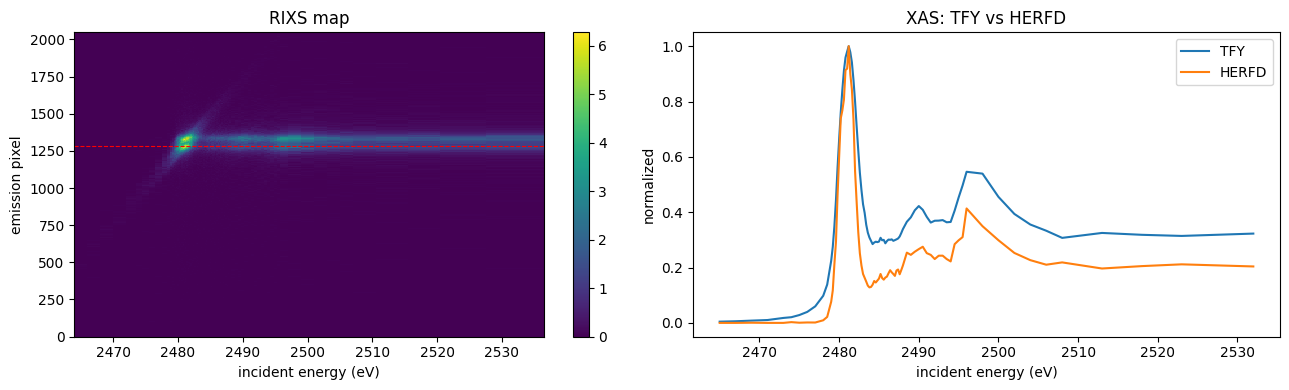

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

im = ax[0].pcolormesh(out.E, np.arange(out.rixs_map.shape[0]), out.rixs_map, shading='auto')
ax[0].set(title='RIXS map', xlabel='incident energy (eV)', ylabel='emission pixel')
ax[0].axhline(out.central_pix, color='r', lw=0.8, ls='--')
fig.colorbar(im, ax=ax[0])

ax[1].plot(out.E, out.TFY / np.nanmax(out.TFY), label='TFY')
ax[1].plot(out.E, out.HERFD / np.nanmax(out.HERFD), label='HERFD')
ax[1].set(title='XAS: TFY vs HERFD', xlabel='incident energy (eV)', ylabel='normalized'); ax[1].legend()

plt.tight_layout()

## 4. `index_beamtime` — Batch analyze an entire directory

A sample directory typically holds all measurements for a single compound collected within a beamtime (many compounds are measured per beamtime, each in its own directory; the function keeps the historical `beamtime` name for backward compatibility). Such a directory holds many measurements mixed together. `index_beamtime` parses the `.sif` filenames and groups them into runnable **`Measurement`** objects — one `OnePot` per XES incident energy, one `OnePotRIXS` per RIXS series — with the`_dark.sif` files auto-paired as the background. 
Files with alternative naming convensions (operando-echem and calibration/alignment files, including elastic scans) are skipped by default (and reported in `.skipped`, never silently dropped).

Each `Measurement` builds and runs the right pipeline via `.run()`, and results can be written to annotated text either at an explicit path (`result.save_txt(path)`) or auto-named into an output directory (`measurement.save_result(result, root=...)`).

In [10]:
from src import index_beamtime

# Index the emission dataset: one XES measurement per incident energy.
idx = index_beamtime('./data/CPMoITriCO3Dimer')
print(f'{len(idx)} measurements found (skipped: {[(k, len(v)) for k, v in idx.skipped.items()]}):')
for m in idx:
    print('  ', m)

7 measurements found (skipped: []):
   Measurement(RIXS, 'CPMoITriCO3Dimer_12mMol_Toluene', La, series 1, 116 files, 1 dark)
   Measurement(RIXS, 'CPMoITriCO3Dimer_12mMol_Toluene', La, series 2, 116 files, 1 dark)
   Measurement(RIXS, 'CPMoITriCO3Dimer_12mMol_Toluene', La, series 3, 116 files, 1 dark)
   Measurement(XES, 'CPMoITriCO3Dimer_12mMol_Toluene', L3val, 2523eV, 18 files, 18 dark)
   Measurement(XES, 'CPMoITriCO3Dimer_12mMol_Toluene', L3val, 2524.2eV, 18 files, 18 dark)
   Measurement(XES, 'CPMoITriCO3Dimer_12mMol_Toluene', L3val, 2525.3eV, 18 files, 18 dark)
   Measurement(XES, 'CPMoITriCO3Dimer_12mMol_Toluene', L3val, 2800eV, 18 files, 18 dark)


In [11]:
# Run one measurement and save it (auto-named into ./data/CPMoITriCO3Dimer/analysis/).
m = idx.by_kind('XES')[3]
result = m.run()                       # dark auto-paired as background
out_paths = m.save_result(result, root='./data/CPMoITriCO3Dimer')
print('\nwrote:', out_paths)


wrote: ['./data/CPMoITriCO3Dimer/analysis/CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2800eV.txt']


### Batch: Run and save every measurement

`idx.run_all(**overrides)` runs every measurement, prints a progress line and summary, and (with `save_root`) auto-saves each result. 
It returns a list of `MeasurementRun` records (`.measurement`, `.result`, `.seconds`, `.error`, `.saved_paths`, `.summary`). 
A measurement that fails is captured on its record rather than aborting the batch. Overrides are keyword arguments passed through to each pipeline — order does not matter.

When `save_root` is given it also writes a JSON **run manifest** to `save_root/analysis/run_manifest.json` (an auditable record of the batch). 
Pass `detail=True` to additionally stream each measurement's own per-file progress.

`scan_nbrs=range(20)` below subsets frames per file to keep this demo quick; drop it to process all frames.

In [12]:
# Run + save all measurements in one call.
runs = idx.run_all(save_root='./data/CPMoITriCO3Dimer', threshold=[100, 170, 350], detail=True)

Running 7 measurement(s)...
OnePotRIXS: excluded 1 dark frame(s) (*_dark.sif) from the scan
OnePotRIXS: 116 file(s), 116 frame(s), background: computed from data (min-projection)
OnePotRIXS: using CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_dark.sif as background (mean ADU 924.5)
  extracting signal from 116 frame(s)...
    (1/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2514.00.sif — frames 0–0
    (2/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2514.40.sif — frames 1–1
    (3/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2514.80.sif — frames 2–2
    (4/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2515.20.sif — frames 3–3
    (5/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2515.60.sif — frames 4–4
    (6/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2516.00.sif — frames 5–5
    (7/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2516.40.sif — frames 6–6
    (8/116) CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_2516.80.sif — frames 7–7
    (9/116) CPMoITriC

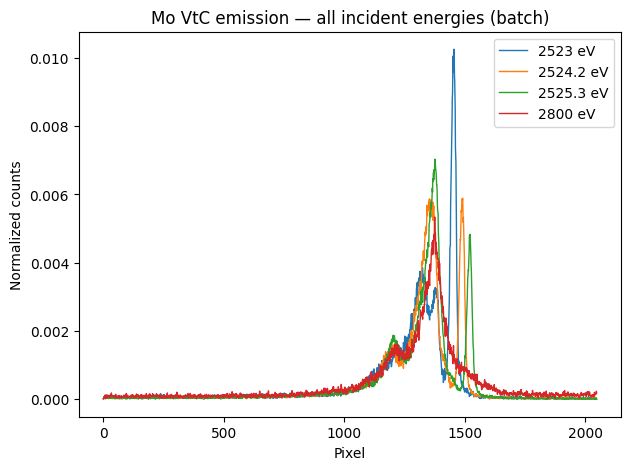

In [13]:
# Overlay the resulting emission spectra (one per incident energy).
plt.figure(figsize=(7, 5))
# Slice for XES only
for run in runs[3:]:
    spec = run.result.spectrum()
    plt.plot(spec / np.trapezoid(spec),
             label=f'{run.measurement.incident_energy:g} eV', lw=1)
plt.title('Mo VtC emission — all incident energies (batch)')
plt.xlabel('Pixel'); plt.ylabel('Normalized counts')
plt.legend()

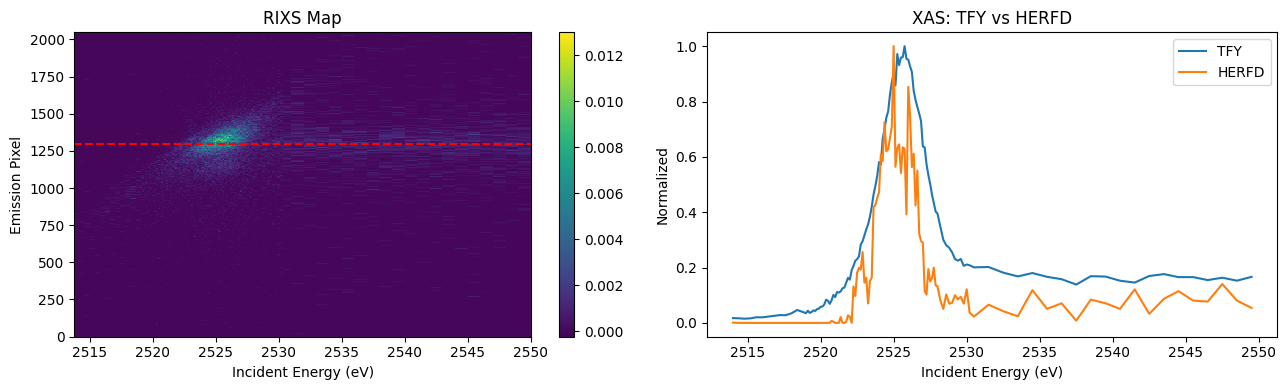

In [14]:
# Example RIXS plot from batch analysis
fig, ax = plt.subplots(1, 2, figsize=(13,4))

img = ax[0].pcolormesh(runs[0].result.E, 
                       np.arange(runs[0].result.rixs_map.shape[0]), 
                       runs[0].result.rixs_map, shading = 'auto')

ax[0].set(title="RIXS Map", xlabel='Incident Energy (eV)', ylabel='Emission Pixel')
ax[0].axhline(runs[0].result.central_pix, color='r', ls = '--')
fig.colorbar(img, ax=ax[0])

ax[1].plot(runs[0].result.E, runs[0].result.TFY / np.nanmax(runs[0].result.TFY), label='TFY')
ax[1].plot(runs[0].result.E, runs[0].result.HERFD / np.nanmax(runs[0].result.HERFD), label='HERFD')
ax[1].set(title="XAS: TFY vs HERFD", xlabel="Incident Energy (eV)", ylabel="Normalized")
ax[1].legend()

plt.tight_layout()

### The run manifest

Because we passed `save_root`, `run_all` wrote a JSON manifest recording every
measurement — its label, ok/failed status, output paths, timing, and a small
result summary. This makes an unattended batch auditable and lets a follow-up job
find which measurements to re-run.

In [15]:
import json

with open('./data/CPMoITriCO3Dimer/analysis/run_manifest.json') as fh:
    manifest = json.load(fh)

print(f"{manifest['n_ok']}/{manifest['n']} ok in {manifest['total_seconds']:.1f}s")
for entry in manifest['measurements']:
    print(f"  {entry['label']:52s} ok={entry['ok']}  {entry['seconds']:.1f}s  {entry['summary']}")

7/7 ok in 398.7s
  CPMoITriCO3Dimer_12mMol_Toluene_La_RIXS_01           ok=True  9.5s  {'kind': 'RIXS', 'central_pix': 1299, 'herfd_sum': 0.5485107170077903}
  CPMoITriCO3Dimer_12mMol_Toluene_La_RIXS_02           ok=True  9.3s  {'kind': 'RIXS', 'central_pix': 1303, 'herfd_sum': 0.8951994923959241}
  CPMoITriCO3Dimer_12mMol_Toluene_La_RIXS_03           ok=True  9.4s  {'kind': 'RIXS', 'central_pix': 1294, 'herfd_sum': 0.614236873983574}
  CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2523eV     ok=True  92.2s  {'kind': 'XES', 'spectrum_sum': 12867848.875018887, 'peak_pixel': 1455}
  CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2524.2eV   ok=True  92.1s  {'kind': 'XES', 'spectrum_sum': 21102629.770342186, 'peak_pixel': 1491}
  CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2525.3eV   ok=True  93.2s  {'kind': 'XES', 'spectrum_sum': 28472969.74256019, 'peak_pixel': 1376}
  CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2800eV     ok=True  93.0s  {'kind': 'XES', 'spectrum_sum': 12239999.389304517, 'peak_pixe

### Parallel execution & many beamtimes

For large re-processing jobs, `run_all(max_workers=N)` runs measurements
concurrently in a process pool (each measurement is an independent unit of work).
Parallel mode **requires** `save_root`: results are written in the worker and
their large arrays dropped before returning (so a big batch doesn't ship arrays
back between processes). The returned records keep `.saved_paths` and a small
`.summary` but `.result` is `None`.

Worker-count resolution is conservative for shared clusters: an explicit
`max_workers` wins; otherwise the SLURM allocation (`SLURM_CPUS_PER_TASK`, then
`SLURM_CPUS_ON_NODE`) is used; if neither is present it **raises** rather than
guess from the machine's core count. `run_beamtimes([...])` applies the same
machinery across many beamtime directories, writing per-beamtime outputs plus a
combined manifest.

**Note:** Because the pool uses the *spawn* start method, a plain `.py` script
must guard its entry point with `if __name__ == "__main__":`. In a notebook it just works. 

The cell below illustrates a `max_workers=4` test case, demonstrating a total job time (130 s) approaching that of the single core XES analysis (90 s) shown above. 

In [31]:
# Illustrative — parallel batch and multi-beamtime driver (left commented so a
# "Run All" doesn't spawn a process pool during this walkthrough).

from src import run_beamtimes
from time import time

#t_start = time()
# Parallel over one directory (save_root is required in parallel mode):
#runs = idx.run_all(save_root='./out/CPMoITriCO3Dimer',
#                   max_workers=4, threshold=[100, 170, 350])
#t_stop = time()
#print("Total time: ", np.round(t_stop-t_start), 'seconds')

# Or many beamtimes at once -> per-beamtime outputs + a combined manifest:
t_start = time()
run_beamtimes(['./data/CPMoITriCO3Dimer', './data/Na2SO4'],
               save_root='./out', max_workers=4, threshold=[100, 170, 350])
t_stop = time()
print("Total time: ", np.round(t_stop-t_start), 'seconds')

# On SLURM, omit max_workers to inherit the allocation (SLURM_CPUS_PER_TASK).
# In a .py script, wrap the call in `if __name__ == "__main__":` (spawn).

=== beamtime: CPMoITriCO3Dimer ===
Running 7 measurement(s) on 4 worker(s)...
  [1/7] CPMoITriCO3Dimer_12mMol_Toluene_La_RIXS_02             11.3s  ok  -> 1 file(s)
  [2/7] CPMoITriCO3Dimer_12mMol_Toluene_La_RIXS_01             11.5s  ok  -> 1 file(s)
  [3/7] CPMoITriCO3Dimer_12mMol_Toluene_La_RIXS_03             12.1s  ok  -> 1 file(s)
  [4/7] CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2523eV      110.2s  ok  -> 1 file(s)
  [5/7] CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2524.2eV    111.6s  ok  -> 1 file(s)
  [6/7] CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2525.3eV    111.5s  ok  -> 1 file(s)
  [7/7] CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2800eV      111.4s  ok  -> 1 file(s)
OnePotRIXS: excluded 1 dark frame(s) (*_dark.sif) from the scan
OnePotRIXS: using CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_02_dark.sif as background (mean ADU 924.3)
OnePotRIXS: excluded 1 dark frame(s) (*_dark.sif) from the scan
OnePotRIXS: using CPMoITriCO3Dimer_12mMol_Toluene_MoLa_RIXS_01_dark.sif as backgro

## 5. Energy calibration — pixel → energy from elastic scattering

The energy-dispersive (pixel) axis is converted to energy by collecting **elastic scattering** at several fixed monochromator energies. At each mono energy the elastically-scattered line lands on a particular detector pixel, so fitting each elastic peak's centre pixel and linear-fitting `(centre_pixel → mono_energy)` yields the `energy = m·pixel + b` conversion.

This is a **standalone, skippable** step. Elastic data is usually reserved for *post-beamtime* analysis (the calibration may not be available while measuring), so it is **never built or required** by the standard workflow above — the elastic `*elastic*.sif` files are skipped by `index_beamtime` (reported in `.skipped`). The calibration API below opts back in explicitly.

Elastic scans are typically stored in their own directory; here they live in `./data/elastic_H2OJet_MoL3val/` (Mo L₃ elastic line at six incident energies, each with a paired `_dark`). Each elastic spectrum is produced by the same `OnePot` single-photon extraction used for XES (a raw frame sum would be swamped by the readout baseline), with the paired dark wired in as the background. A matching `_dark.sif` at each energy is **required** — pairing elastic and dark at the same energy is the calibration protocol (best S/N and accuracy), so a missing dark raises an error rather than running without a background.

In [ ]:
from src import index_elastic, ElasticCalibration, calibrate_from_directory

# Index the elastic scans (each *elastic*.sif at its fixed mono energy, paired
# _dark used as background) and extract one emission spectrum per energy.
points = index_elastic('./data/elastic_H2OJet_MoL3val', threshold=[100, 170, 350])
print(f'{len(points)} elastic points:')
for p in points:
    print(f'  {p.energy:8.2f} eV   peak near pixel {int(np.argmax(p.spectrum))}')

# Fit centre pixel per elastic line (Lorentzian), then a linear pixel->energy fit.
cal = ElasticCalibration.fit(points)
print('\n', cal)

# One-liner equivalent: cal = calibrate_from_directory('./data/elastic_H2OJet_MoL3val',
#                                                       threshold=[100, 170, 350])

# Persist for reuse (post-beamtime calibrations are often shared across samples).
cal.save_json('./data/elastic_H2OJet_MoL3val/calibration.json')
# cal = ElasticCalibration.load_json('./data/elastic_H2OJet_MoL3val/calibration.json')

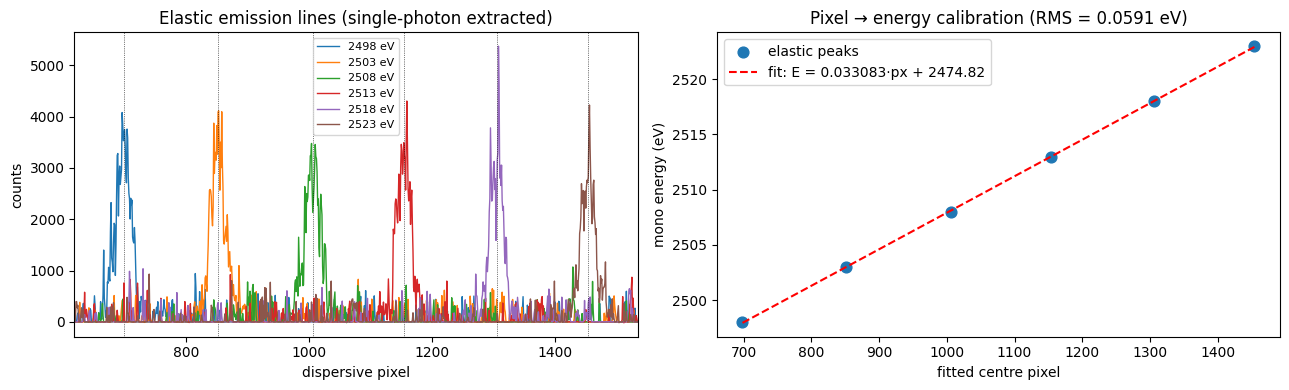

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# left: each elastic emission spectrum, with its fitted centre pixel marked
for pt, c in zip(points, cal.centers):
    ax[0].plot(pt.spectrum, lw=1, label=f'{pt.energy:g} eV')
    ax[0].axvline(c, color='k', lw=0.5, ls=':')
ax[0].set(title='Elastic emission lines (single-photon extracted)',
          xlabel='dispersive pixel', ylabel='counts',
          xlim=(cal.centers.min() - 80, cal.centers.max() + 80))
ax[0].legend(fontsize=8)

# right: the linear pixel -> energy calibration fit
ax[1].scatter(cal.centers, cal.energies, s=60, label='elastic peaks')
px = np.linspace(cal.centers.min(), cal.centers.max(), 100)
ax[1].plot(px, cal.to_energy(px), 'r--',
           label=f'fit: E = {cal.m:.5g}·px + {cal.b:.2f}')
ax[1].set(title=f'Pixel → energy calibration (RMS = {cal.rms:.3g} eV)',
          xlabel='fitted centre pixel', ylabel='mono energy (eV)')
ax[1].legend()
plt.tight_layout()

### Apply the calibration — convert spectra to an energy axis

Standard results stay in pixel space; a calibration is applied **only when supplied**. Pass it to `save_txt(path, calibration=cal)` (or `save_result(..., calibration=cal)`) and the XES export gains an `energy_eV` column (`pixel, energy_eV, counts`), with the coefficients recorded in the header. `to_energy(pixels)` converts an axis for plotting.

The calibration applies to the **emission** (pixel) axis, so it is dropped for RIXS results (whose export already carries an *incident*-energy axis) — a mixed-kind batch stays safe.

wrote: ['./data/CPMoITriCO3Dimer/analysis/CPMoITriCO3Dimer_12mMol_Toluene_L3val_XES_2523eV.txt']


(2514.523431924696, 2527.756535515979)

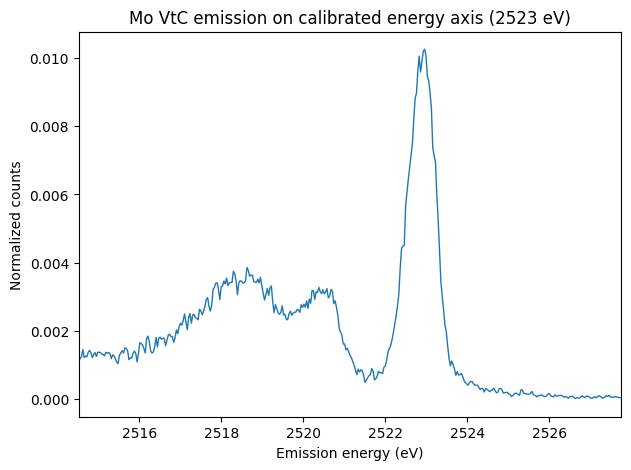

In [16]:
# Apply the calibration to an XES measurement's export: the emission spectrum
# gains an `energy_eV` column. Without a calibration, save_txt is unchanged.
xes_m = idx.by_kind('XES')[0]
xes_res = xes_m.run(threshold=[100, 170, 350])

# Save with the calibration -> columns become: pixel, energy_eV, counts
paths = xes_m.save_result(xes_res, root='./data/CPMoITriCO3Dimer', calibration=cal)
print('wrote:', paths)

# Plot the emission spectrum on the calibrated energy axis.
spec = xes_res.spectrum()
energy = cal.to_energy(np.arange(spec.size))

plt.figure(figsize=(7, 5))
plt.plot(energy, spec / np.trapezoid(spec), lw=1)
plt.title(f'Mo VtC emission on calibrated energy axis ({xes_m.incident_energy:g} eV)')
plt.xlabel('Emission energy (eV)'); plt.ylabel('Normalized counts')
plt.xlim(cal.to_energy(1200), cal.to_energy(1600))

# For a whole batch, forward the calibration through run_all's save_kwargs:
#   idx.run_all(save_root='./out', threshold=[100, 170, 350],
#               save_kwargs={'calibration': cal})   # dropped for RIXS results